In [100]:
# type: ignore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.utils import image_dataset_from_directory

In [101]:
print("Tensorflow Version: ", tf.__version__)
print("Keras Version: ", keras.__version__)
print("Numpy Version: ", np.__version__)

Tensorflow Version:  2.18.0
Keras Version:  3.8.0
Numpy Version:  1.26.4


In [102]:
def load_train_data():
    train_set = image_dataset_from_directory(
        directory='./data/seg_train',
        labels='inferred',
        label_mode='categorical',
        color_mode='rgb',
        image_size=(256, 256),
        shuffle=True,
        seed=42
    )
    return train_set

def load_pred_data():
    pred_set = image_dataset_from_directory(
        directory='./data/seg_pred',
        labels='inferred',
        label_mode='categorical',
        color_mode='rgb',
        image_size=(256, 256),
        shuffle=True,
        seed=42
    )
    return pred_set

def load_test_data():
    test_set = image_dataset_from_directory(
        directory='./data/seg_test',
        labels='inferred',
        label_mode='categorical',
        color_mode='rgb',
        image_size=(256, 256),
        shuffle=True,
        seed=42
    )
    return test_set

#### This is really cool and much better than having to make my own function for this.

In [103]:
train_set = load_train_data()
pred_set = load_pred_data()
test_set = load_test_data()

Found 14034 files belonging to 6 classes.
Found 7301 files belonging to 1 classes.
Found 3000 files belonging to 1 classes.


In [104]:
class_names = train_set.class_names
class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

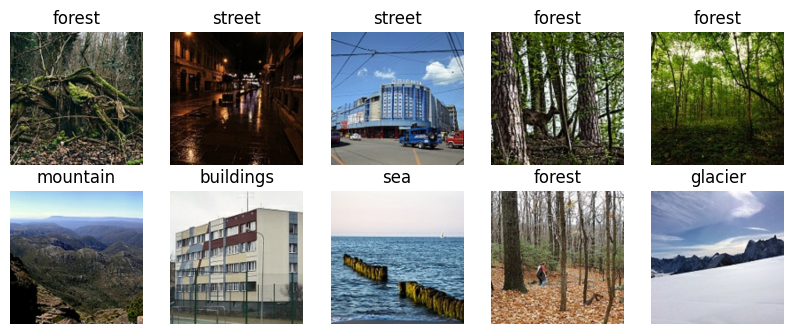

In [105]:
plt.figure(figsize=(10,10))
for images, labels in train_set.take(1):
    for i in range(10):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"));
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis('off')

In [106]:
class_counts = {}
for class_name in os.listdir('./data/seg_train'):
    class_dir = os.path.join('./data/seg_train', class_name)
    if os.path.isdir(class_dir):
        class_counts[class_name] = len(os.listdir(class_dir))
for class_name, count in class_counts.items():
    print(f'{class_name}: {count} images')

forest: 2271 images
buildings: 2191 images
glacier: 2404 images
street: 2382 images
mountain: 2512 images
sea: 2274 images


Text(0, 0.5, 'Number of images')

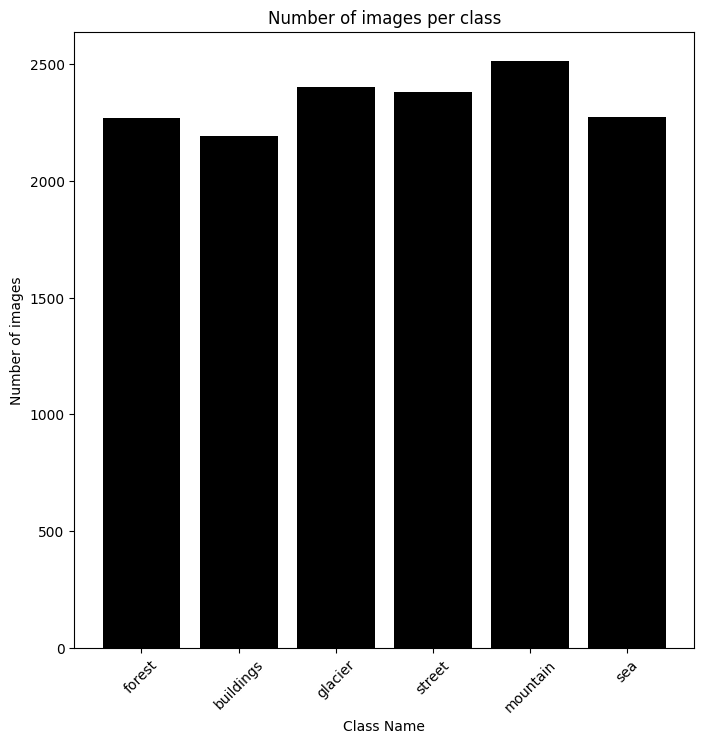

In [107]:
plt.figure(figsize=(8,8))
plt.bar(class_counts.keys(), class_counts.values(), color='black');
plt.title('Number of images per class')
plt.xticks(rotation=45)
plt.xlabel('Class Name')
plt.ylabel('Number of images')

#### Intel's dataset wasn't stratified by class name 😔

In [108]:
Norm_layer = Rescaling(1 / 255)
train_set = train_set.map(lambda x, y: (Norm_layer(x), y))
pred_set = pred_set.map(lambda x, y: (Norm_layer(x), y))
test_set = test_set.map(lambda x, y: (Norm_layer(x), y))

In [109]:
model = Sequential()

model.add(layers.Input(shape=(228, 228, 3)))
model.add(layers.Conv2D(32,kernel_size=(5,5),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(32,kernel_size=(5,5),activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(32,kernel_size=(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(Dense(units=1024,activation='relu'))
model.add(layers.Dropout(0.20))
model.add(Dense(124,activation='relu'))
model.add(layers.Dropout(0.20))
model.add(Dense(units=len(class_names),activation='softmax'))

In [110]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 108, 108, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │     1,639,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 124)            │       127,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 124)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           750 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,860,010 (7.10 MB)

 Trainable params: 1,860,010 (7.10 MB)

 Non-trainable params: 0 (0.00 B)

In [114]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

train_set, _ = train_test_split(list(train_set), test_size=0.9, random_state=42)

train_set = tf.data.Dataset.from_tensor_slices(train_set)

train_set = train_set.map(lambda x, y: (x, tf.one_hot(tf.argmax(y, axis=-1), depth=len(class_names))))
test_set = test_set.map(lambda x, y: (x, tf.one_hot(tf.argmax(y, axis=-1), depth=len(class_names))))

history = model.fit(train_set, validation_data=test_set, epochs=1, callbacks=[early_stopping])

InvalidArgumentError: {{function_node __wrapped__Pack_N_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Shapes of all inputs must match: values[0].shape = [32,256,256,3] != values[1].shape = [32,6] [Op:Pack] name: 0